# 01 · Nền tảng RAG và Indexing (Người 1, slide 6–9)

Từ dữ liệu thô đến chỉ mục vector: khảo sát, làm sạch, chunk, embed, lưu vào Qdrant.

**Đầu ra cho người sau:** `data/listings_clean.parquet` (có `listing_id`) và collection Qdrant `listings_sample`.

**Cần chạy trước:** `docker compose up -d --wait vector_db`.

**Cầu nối sang Người 2:** P1-11 in top-3 của câu "Căn hộ 2PN ở Thủ Đức giá bao nhiêu?". Có chỉ mục rồi, Người 2 làm cho nó tìm đúng và trả lời có căn cứ.

In [1]:
%run ./00_setup.ipynb

### P1-01 · Dataset có 19 cột; đọc theo luồng 20.000 tin đầu là đủ cho trình bày
**CACHE** · slide 6 · Người 1

Mục tiêu: nạp dataset tinixai/vietnam-real-estates, in shape, danh sách cột và 3 dòng mẫu.

In [2]:
# P1-01 · CACHE
raw = cached("raw.parquet", lambda: data.load_raw(N_ROWS))
print("shape:", raw.shape)
print("cột:", list(raw.columns))
show(raw, ["listing_id", COL["title"], COL["property_type"], COL["district"], COL["price"], COL["area"]], rows=3)

shape: (20000, 20)
cột: ['listing_id', 'name', 'description', 'property_type_name', 'province_name', 'district_name', 'ward_name', 'street_name', 'project_name', 'price', 'area', 'floor_count', 'frontage_width', 'house_depth', 'road_width', 'bedroom_count', 'bathroom_count', 'house_direction', 'balcony_direction', 'published_at']


,listing_id,name,property_type_name,district_name,price,area
0,1,"Bán nhanh nhà 6 tầng thang máy, ngoạ long cầu diễn, ôtô đỗ cổng, giá: 7.45 t...",Nhà,Bắc Từ Liêm,7.450000e+09,37.0
1,2,Bán gấp nhà mặt tiền 4 tầng khu phân lô Tạ Quang Bửu,Nhà,8,9.100000e+09,48.0
2,3,"Bán biệt thự 300m2 gần sân bóng Bình Minh, đường rộng, nội thất đầy đủ",Biệt thự/Nhà liền kề,Bình Minh,2.000000e+10,300.0


### P1-02 · Mô tả gần như đủ, nhưng hơn nửa số tin thiếu số phòng ngủ
**CACHE** · slide 6 · Người 1

Mục tiêu: khảo sát kiểu dữ liệu, tỷ lệ thiếu, tin trùng, độ dài mô tả.

In [3]:
# P1-02 · CACHE
quality = cached("p1_02_quality.parquet", lambda: data.quality_summary(raw).reset_index(names="cột"))
print("tin trùng (tiêu đề + mô tả):", data.duplicate_count(raw))
print("độ dài mô tả (số từ):", data.description_length_stats(raw).to_dict())
quality.sort_values("% thiếu", ascending=False)

tin trùng (tiêu đề + mô tả): 74


độ dài mô tả (số từ): {'count': 20000.0, 'mean': 119.0, 'std': 73.0, 'min': 0.0, '50%': 103.0, '90%': 204.0, '99%': 392.0, 'max': 676.0}


,cột,kiểu,% thiếu,số giá trị khác nhau
13,house_depth,float64,96.2,292
14,road_width,float64,91.3,83
11,floor_count,float64,85.2,15
18,balcony_direction,str,84.7,12
8,project_name,str,75.2,1420
17,house_direction,str,67.8,12
16,bathroom_count,float64,53.8,28
15,bedroom_count,float64,50.8,29
12,frontage_width,float64,46.5,364
7,street_name,str,40.6,2381


### P1-03 · Giá/m² lệch phải mạnh, hai thành phố lớn chiếm phần lớn tin
**LIVE** · slide 6 · Người 1

Mục tiêu: vẽ phân phối giá/m² và số tin theo tỉnh; tiêu đề biểu đồ là kết luận tính từ dữ liệu.

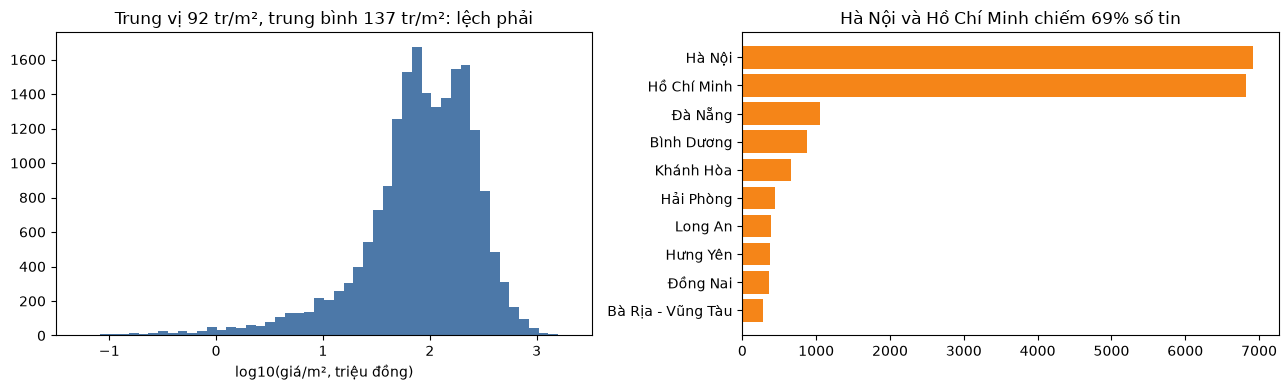

In [4]:
# P1-03 · LIVE
pm2 = (raw[COL["price"]] / raw[COL["area"]] / 1e6).replace([np.inf, -np.inf], np.nan).dropna()
pm2 = pm2[(pm2 > 0.05) & (pm2 < 2000)]
by_prov = raw[COL["province"]].value_counts().head(10)
share = by_prov.iloc[:2].sum() / len(raw)

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4))
a.hist(np.log10(pm2), bins=50, color="#4C78A8")
a.set_xlabel("log10(giá/m², triệu đồng)")
a.set_title(f"Trung vị {pm2.median():.0f} tr/m², trung bình {pm2.mean():.0f} tr/m²: lệch phải")
b.barh(by_prov.index[::-1], by_prov.values[::-1], color="#F58518")
b.set_title(f"{by_prov.index[0]} và {by_prov.index[1]} chiếm {share:.0%} số tin")
plt.tight_layout()

### P1-04 · Làm sạch bỏ 75 tin trùng hoặc rỗng, chuẩn hoá giá và địa danh
**CACHE** · slide 6 · Người 1

Mục tiêu: chuẩn hoá đơn vị giá, bỏ trùng, chuẩn hoá địa danh, ẩn số điện thoại; in số dòng trước và sau.

In [5]:
# P1-04 · CACHE
df, steps = cached("p1_04_clean.pkl", lambda: data.clean(raw))
print(pd.Series(steps, name="số dòng").to_string())

# Ví dụ 1 dòng trước và sau: quận/phường dạng số ở Hồ Chí Minh
i = raw.index[raw[COL["district"]].astype(str).str.fullmatch(r"\d+")][0]
before = raw.loc[i, [COL["district"], COL["ward"], COL["price"], COL["title"]]].tolist()
after = df.set_index("listing_id").loc[raw.loc[i, "listing_id"], ["district", "ward", "price_bn", "title"]].tolist()
pd.DataFrame({"trước": before, "sau": after}, index=["quận", "phường", "giá", "tiêu đề"])

ban đầu                                                20000
bỏ tin thiếu cả tiêu đề và mô tả                       19998
bỏ tin trùng tiêu đề + mô tả                           19925
sửa giá nhập theo nghìn đồng (48 tin, bỏ giá 5 tin)    19925
sau chuẩn hoá giá và địa danh                          19925


,trước,sau
quận,8,Quận 8
phường,5,Phường 5
giá,9100000000.0,9.1
tiêu đề,Bán gấp nhà mặt tiền 4 tầng khu phân lô Tạ Quang Bửu,Bán gấp nhà mặt tiền 4 tầng khu phân lô Tạ Quang Bửu


### P1-05 · Cả nhóm dùng chung một file dữ liệu sạch có listing_id ổn định
**ẨN** · slide 6 · Người 1

Mục tiêu: lưu data/listings_clean.parquet; listing_id là số thứ tự dòng trong dataset gốc.

In [6]:
# P1-05 · ẨN
assert df["listing_id"].is_unique
df.to_parquet(CLEAN_PATH, index=False)
print(CLEAN_PATH.relative_to(ROOT), "|", len(df), "dòng")

data/listings_clean.parquet | 19925 dòng


### P1-06 · Chunking: n = 7 khớp với đếm thực
**LIVE** · slide 7 · Người 1

Mục tiêu: cắt 1 mô tả dài bằng chiến lược cố định rồi bằng 1 tin = 1 chunk; tính n theo công thức và đối chiếu.

In [7]:
# P1-06 · LIVE
L, S, O = 2000, 400, 100
n_thuc, n_cong_thuc = len(data.chunk_starts(L, S, O)), data.n_chunks_formula(L, S, O)
assert n_thuc == n_cong_thuc == 7
print("toy:", n_thuc, "chunk | vị trí:", data.chunk_starts(L, S, O))

tok = vector.embedder().tokenizer
long = df.loc[df["description"].str.len().idxmax()].to_dict()
fixed, whole = data.chunk_listing(long, tok), data.chunk_listing(long, tok, strategy="whole")
L_real, S_real = len(tok.encode(long["description"], add_special_tokens=False)), data.body_budget(long, tok)
assert len(fixed) == data.n_chunks_formula(L_real, S_real, CHUNK_OVERLAP)
print(f"tin #{long['listing_id']}: L = {L_real} token, S = {S_real} (sau header), O = {CHUNK_OVERLAP}")
print(f"cố định: n = {len(fixed)} = công thức | 1 tin = 1 chunk: {whole[0]['n_tokens']} token, "
      f"E5 chỉ đọc 512 token đầu")

toy: 7 chunk | vị trí: [0, 300, 600, 900, 1200, 1500, 1800]


tin #10877: L = 771 token, S = 350 (sau header), O = 100
cố định: n = 3 = công thức | 1 tin = 1 chunk: 820 token, E5 chỉ đọc 512 token đầu


### P1-07 · 19.925 tin thành 21.030 chunk, chỉ 4,8% tin cần hơn 1 chunk
**CACHE** · slide 7 · Người 1

Mục tiêu: dựng chunk cho toàn bộ tin, gắn metadata tỉnh, quận, giá, diện tích, loại hình.

21030 chunk từ 19925 tin | 4.8% tin có hơn 1 chunk


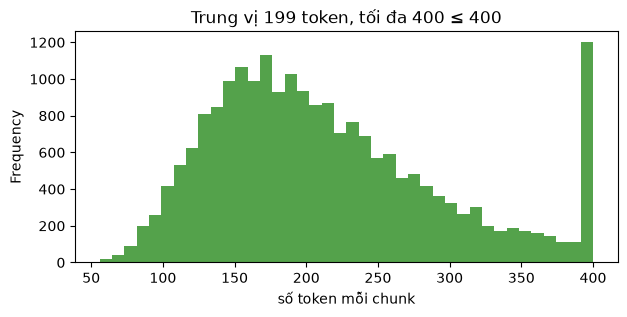

In [8]:
# P1-07 · CACHE
tok = vector.embedder().tokenizer
chunks = cached(CHUNKS_PATH, lambda: data.build_chunks(df, tok))
print(f"{len(chunks)} chunk từ {chunks.listing_id.nunique()} tin | "
      f"{(chunks.groupby('listing_id').size() > 1).mean():.1%} tin có hơn 1 chunk")
ax = chunks["n_tokens"].plot.hist(bins=40, figsize=(7, 3), color="#54A24B")
ax.set_xlabel("số token mỗi chunk")
ax.set_title(f"Trung vị {chunks.n_tokens.median():.0f} token, tối đa {chunks.n_tokens.max()} ≤ {CHUNK_SIZE}");

### P1-08 · Câu gần nghĩa nằm gần nhau trong không gian embedding
**LIVE** · slide 8 · Người 1

Mục tiêu: embed 5 câu mẫu (2 cặp gần nghĩa, 1 câu khác chủ đề), chiếu 2D bằng PCA.

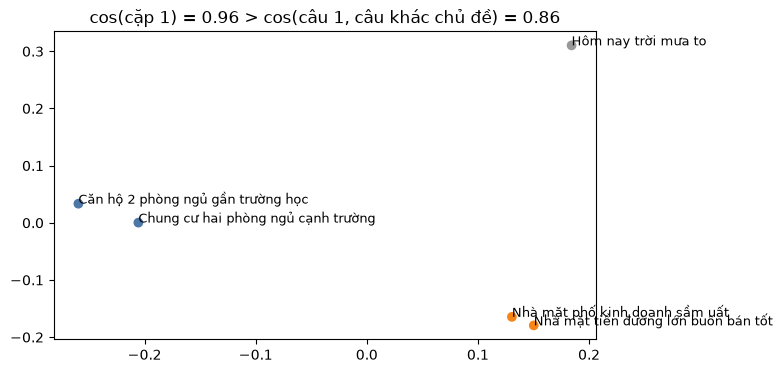

In [9]:
# P1-08 · LIVE
from sklearn.decomposition import PCA
sentences = ["Căn hộ 2 phòng ngủ gần trường học", "Chung cư hai phòng ngủ cạnh trường",
             "Nhà mặt phố kinh doanh sầm uất", "Nhà mặt tiền đường lớn buôn bán tốt",
             "Hôm nay trời mưa to"]
E = vector.embed_passages(sentences)
sim = E @ E.T
assert sim[0, 1] > sim[0, 4] and sim[2, 3] > sim[2, 4]
xy = PCA(2, random_state=SEED).fit_transform(E)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(xy[:, 0], xy[:, 1], c=["#4C78A8"] * 2 + ["#F58518"] * 2 + ["#999"])
for (x, y), s in zip(xy, sentences):
    ax.annotate(s, (x, y), fontsize=9)
ax.set_title(f"cos(cặp 1) = {sim[0, 1]:.2f} > cos(câu 1, câu khác chủ đề) = {sim[0, 4]:.2f}");

### P1-09 · Embed 21.030 chunk mất khoảng 2 phút trên GPU, chiếm 32 MB
**CACHE** · slide 9 · Người 1

Mục tiêu: embed toàn bộ chunk, lưu index/embeddings.npy; in thời gian, kích thước vector, dung lượng.

In [10]:
# P1-09 · CACHE
def embed_all():
    with Timer() as t:
        np.save(EMBEDDINGS_PATH, vector.embed_passages(chunks["text"].tolist()))
    return {"seconds": round(t.seconds, 1)}

stats = cached("p1_09_embed.json", embed_all, rebuild=REBUILD or not EMBEDDINGS_PATH.exists())
emb = np.load(EMBEDDINGS_PATH)
assert len(emb) == len(chunks)
print(f"thời gian embed: {stats['seconds']} s | vector: {emb.shape} {emb.dtype} | "
      f"dung lượng: {EMBEDDINGS_PATH.stat().st_size / 1e6:.1f} MB")

thời gian embed: 133.1 s | vector: (21030, 384) float32 | dung lượng: 32.3 MB


### P1-10 · Vector DB chứa đúng số chunk, kèm metadata để lọc
**CACHE** · slide 9 · Người 1

Mục tiêu: nạp vào Qdrant (dense + BM25 sparse) kèm metadata; count() khớp số chunk.

In [11]:
# P1-10 · CACHE
# Mỗi chunk là một point: vector dense E5 + vector sparse BM25 (từ tách bằng pyvi) + payload để lọc.
tokens = cached("bm25_tokens.pkl", lambda: [rag.tokenize_vi(t) for t in chunks["text"]])
if REBUILD or qdrant_store.count() != len(chunks):
    with Timer() as t:
        qdrant_store.load(chunks, df, emb, tokens)
    print(f"nạp Qdrant trong {t.seconds:.0f} s")
qdrant_store.write_manifest({"listings": len(df), "chunks": len(chunks), "price_sum": float(df["price"].sum())})
assert qdrant_store.count() == len(chunks)
print(f"Qdrant {QDRANT_COLLECTION}: count() = {qdrant_store.count()} = số chunk {len(chunks)}")
point = qdrant_store.client().retrieve(QDRANT_COLLECTION, ids=[1000], with_payload=True)[0]
{k: v for k, v in point.payload.items() if k not in ("text", "description")}

Qdrant listings_sample: count() = 21030 = số chunk 21030


{'listing_id': 1,
 'chunk_index': 0,
 'title': 'Bán nhanh nhà 6 tầng thang máy, ngoạ long cầu diễn, ôtô đỗ cổng, giá: 7.45 tỷ, lh [phone_number]',
 'property_type': 'Nhà',
 'province': 'Hà Nội',
 'district': 'Bắc Từ Liêm',
 'ward': 'Phúc Diễn',
 'street': 'Ngọa Long',
 'price': 7450000000.0,
 'area': 37.0,
 'bedrooms': 4.0,
 'bathrooms': 5.0,
 'published_at': '2025-06-01T05:12:56.941000',
 'price_m2_mil': 201.35135135135135}

### P1-11 · Chỉ mục đã tìm được tin liên quan, nhưng chưa lọc đúng điều kiện
**LIVE** · slide 9 · Người 1

Mục tiêu: kiểm tra nhanh: 1 câu hỏi, in top-3 kèm ID, điểm, giá, địa chỉ.

In [12]:
# P1-11 · LIVE
q = "Căn hộ 2PN ở Thủ Đức giá bao nhiêu?"
hits = qdrant_store.search(vector.embed_query(q).tolist(), "dense", limit=3)
pd.DataFrame({"listing_id": hits.listing_id, "điểm": hits.score.round(4), "giá": hits.price.map(fmt_vnd),
              "phòng ngủ": hits.bedrooms,
              "địa chỉ": hits[["ward", "district", "province"]].apply(
                  lambda r: ", ".join(x for x in r if isinstance(x, str)), axis=1)})

,listing_id,điểm,giá,phòng ngủ,địa chỉ
0,15405,0.9147,"5,70 tỷ",2.0,Hồ Chí Minh
1,3138,0.9118,"3,15 tỷ",2.0,"Thủ Đức, Hồ Chí Minh"
2,18456,0.9099,"1,95 tỷ",3.0,"Tân Phú, Thủ Đức, Hồ Chí Minh"
